# ECS7013P Coursework: Bird Species Classification + Sound Event Detection



## 0. Install Dependencies


In [ ]:
!pip install librosa birdnetlib matplotlib scikit-learn tqdm pandas seaborn -q

## 1. Load Dataset


In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# --- Update this path to where your zip is in Drive ---
ZIP_PATH = '/content/drive/MyDrive/Audio.zip'  # <-- change this
EXTRACT_TO = Path('/content/data/Audio')
EXTRACT_TO.mkdir(parents=True, exist_ok=True)

print("Extracting... this will take a few minutes")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    files = z.namelist()
    mp3s = [f for f in files if f.endswith('.mp3')]
    print(f"Total files: {len(mp3s)}")
    print(f"Example: {mp3s[0]}")
    z.extractall(EXTRACT_TO)



Mounted at /content/drive
Extracting... this will take a few minutes
Total files: 926
Example: Training/Fringillidae_Serinus_canicollis_South Africa_2014-10-28_XC280667_song.mp3


In [ ]:
import pandas as pd
from pathlib import Path

AUDIO_DIR = Path('/content/data/Audio')
MAX_PER_SPECIES = 50  # cap to keep training fast

# --- Guard: check the audio directory exists and contains files ---
if not AUDIO_DIR.exists():
    raise FileNotFoundError(
        f"Audio directory not found: {AUDIO_DIR}\n"
        "Make sure you have extracted the dataset and it is mounted at /content/data/Audio"
    )

metadata = []
for mp3 in sorted(AUDIO_DIR.rglob('*.mp3')):
    parts = mp3.stem.split('_')
    # Format: Family_Genus_species_Country_Date_XCID_type
    if len(parts) < 3:
        continue
    species = parts[1] + '_' + parts[2]  # e.g. Hypocnemis_cantator
    metadata.append({'path': str(mp3), 'species': species})

# --- Guard: check we actually found audio files ---
if not metadata:
    raise ValueError(
        f"No .mp3 files found under {AUDIO_DIR}\n"
        "Check that the path is correct and the dataset has been extracted."
    )

meta_df = pd.DataFrame(metadata)
print(f"Found {len(meta_df)} recordings before filtering")
print(f"Columns: {meta_df.columns.tolist()}")
print(f"Sample species values: {meta_df['species'].unique()[:5]}")

# Keep only species with at least 10 recordings
counts = meta_df['species'].value_counts()
valid_species = counts[counts >= 10].index.tolist()
meta_df = meta_df[meta_df['species'].isin(valid_species)]

# Cap at MAX_PER_SPECIES per species
meta_df = meta_df.groupby('species').head(MAX_PER_SPECIES).reset_index(drop=True)

# Keep top 10 species by count for manageable training
top10 = meta_df['species'].value_counts().head(10).index.tolist()
meta_df = meta_df[meta_df['species'].isin(top10)].reset_index(drop=True)

meta_df.to_csv('/content/data/metadata.csv', index=False)
print(f'Total recordings: {len(meta_df)}')
print(f'Species ({len(top10)}):')
print(meta_df.groupby('species').size().to_string())


Found 926 recordings before filtering
Columns: ['path', 'species']
Sample species values: ['Serinus_canicollis' 'Serinus_serinus' 'Hypocnemis_cantator'
 'Hypocnemis_hypoxantha' 'Hypocnemis_peruviana']
Total recordings: 444
Species (10):
species
Catharus_aurantiirostris    50
Catharus_guttatus           37
Catharus_ustulatus          33
Saxicola_rubetra            50
Saxicola_rubicola           50
Serinus_serinus             50
Troglodytes_aedon           50
Troglodytes_hiemalis        39
Troglodytes_pacificus       35
Troglodytes_troglodytes     50


## 2. Audio Preprocessing — Mel-Spectrograms


In [ ]:
# ── Reproducibility seeds ────────────────────────────────────────────────────
import random, numpy as np, torch
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Seeds set to {SEED} for reproducibility.')


Seeds set to 42 for reproducibility.


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


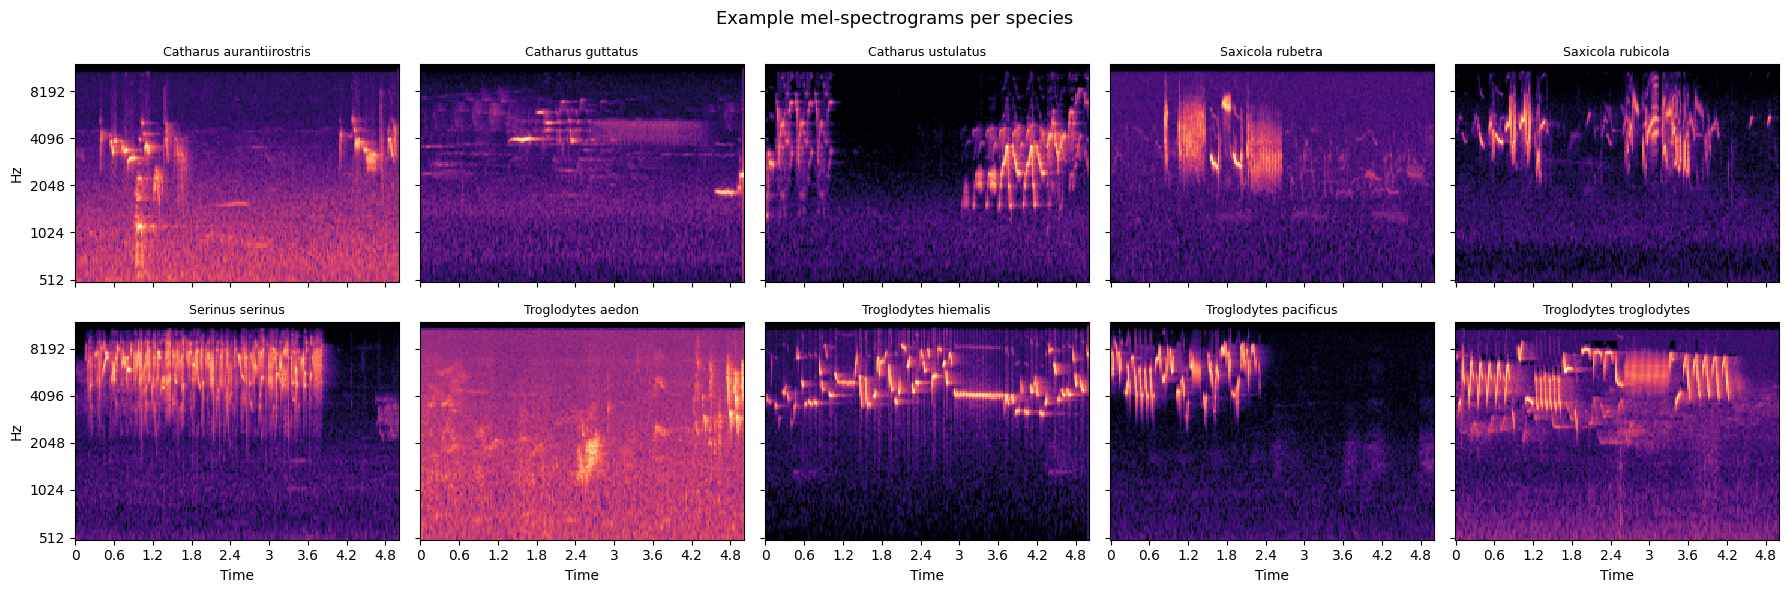

Spectrogram shape: (128, 216)


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

SR       = 22050
DURATION = 5.0
N_MELS   = 128
HOP_LEN  = 512
N_FFT    = 1024
F_MIN    = 500
F_MAX    = 12000

def load_clip(path, sr=SR, duration=DURATION):
    y, _ = librosa.load(path, sr=sr, mono=True)
    n = int(sr * duration)
    if len(y) < n:
        y = np.pad(y, (0, n - len(y)))
    else:
        start = np.random.randint(0, len(y) - n)
        y = y[start:start + n]
    return y

def to_melspec(y, sr=SR):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LEN,
        fmin=F_MIN, fmax=F_MAX)
    return librosa.power_to_db(mel, ref=np.max)

# Visualise one example per species
species_list = sorted(meta_df['species'].unique())
n = len(species_list)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flat

for ax, sp in zip(axes, species_list):
    row = meta_df[meta_df['species'] == sp].iloc[0]
    y = load_clip(row['path'])
    spec = to_melspec(y)
    librosa.display.specshow(spec, sr=SR, hop_length=HOP_LEN,
                             x_axis='time', y_axis='mel',
                             fmin=F_MIN, fmax=F_MAX, ax=ax)
    ax.set_title(sp.replace('_', ' '), fontsize=9)
    ax.label_outer()

for ax in list(axes)[n:]:
    ax.set_visible(False)

plt.suptitle('Example mel-spectrograms per species', fontsize=13)
plt.tight_layout()
plt.savefig('/content/data/spectrograms.png', dpi=100)
plt.show()
print('Spectrogram shape:', spec.shape)

## 3. PyTorch Dataset & Splits


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

SPECIES_LIST = sorted(meta_df['species'].unique())
LABEL2IDX    = {s: i for i, s in enumerate(SPECIES_LIST)}
NUM_CLASSES  = len(SPECIES_LIST)
print(f'Number of classes: {NUM_CLASSES}')
print('Label map:', LABEL2IDX)

class BirdDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths   = paths
        self.labels  = labels
        self.augment = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        y = load_clip(self.paths[idx])
        if self.augment:
            rate = np.random.uniform(0.9, 1.1)
            y = librosa.effects.time_stretch(y, rate=rate)
            n = int(SR * DURATION)
            y = y[:n] if len(y) > n else np.pad(y, (0, n - len(y)))
        spec = to_melspec(y)
        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        spec = (spec - spec.mean()) / (spec.std() + 1e-8)
        return spec, torch.tensor(self.labels[idx], dtype=torch.long)

all_paths  = meta_df['path'].tolist()
all_labels = [LABEL2IDX[s] for s in meta_df['species']]

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

print(f'Train: {len(X_tr)}  Val: {len(X_val)}  Test: {len(X_test)}')

train_loader = DataLoader(BirdDataset(X_tr,   y_tr,   augment=True),  batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(BirdDataset(X_val,  y_val,  augment=False), batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(BirdDataset(X_test, y_test, augment=False), batch_size=16, shuffle=False, num_workers=2)

Number of classes: 10
Label map: {'Catharus_aurantiirostris': 0, 'Catharus_guttatus': 1, 'Catharus_ustulatus': 2, 'Saxicola_rubetra': 3, 'Saxicola_rubicola': 4, 'Serinus_serinus': 5, 'Troglodytes_aedon': 6, 'Troglodytes_hiemalis': 7, 'Troglodytes_pacificus': 8, 'Troglodytes_troglodytes': 9}
Train: 310  Val: 67  Test: 67


## 4. Task A — Self-Implemented CNN Classifier



In [ ]:
import torch.nn as nn
import torch.optim as optim

class BirdCNN(nn.Module):
    """
    4-block CNN for bird species classification from mel-spectrograms.
    Input:  (batch, 1, 128, T)
    Output: (batch, NUM_CLASSES)
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,128,3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

model = BirdCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')
print(model)

Device: cuda
Parameters: 768,074
BirdCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=

### 4a. Hyperparameter Selection — Learning Rate Comparison



In [ ]:
# ── Hyperparameter ablation: learning rate ──────────────────────────────────
import torch, torch.nn as nn, torch.optim as optim

LR_CANDIDATES = [1e-4, 1e-3, 3e-3]
PROBE_EPOCHS   = 10
lr_results     = {}

for lr_cand in LR_CANDIDATES:
    probe_model = BirdCNN().to(DEVICE)
    probe_opt   = optim.Adam(probe_model.parameters(), lr=lr_cand, weight_decay=1e-4)
    probe_sched = optim.lr_scheduler.CosineAnnealingLR(probe_opt, T_max=PROBE_EPOCHS)
    best_probe_acc = 0.0
    for ep in range(PROBE_EPOCHS):
        probe_model.train()
        for specs, labels in train_loader:
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)
            probe_opt.zero_grad()
            nn.CrossEntropyLoss()(probe_model(specs), labels).backward()
            probe_opt.step()
        probe_sched.step()
        probe_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for specs, labels in val_loader:
                specs, labels = specs.to(DEVICE), labels.to(DEVICE)
                correct += (probe_model(specs).argmax(1) == labels).sum().item()
                total   += labels.size(0)
        acc = correct / total
        if acc > best_probe_acc:
            best_probe_acc = acc
    lr_results[lr_cand] = best_probe_acc
    print(f'  lr={lr_cand:.0e}  best val acc (10 ep) = {best_probe_acc:.3f}')

best_lr = max(lr_results, key=lr_results.get)
print(f'\nSelected lr = {best_lr:.0e}  (highest val accuracy in probe run)')


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

  lr=1e-04  best val acc (10 ep) = 0.403


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

  lr=1e-03  best val acc (10 ep) = 0.537


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

  lr=3e-03  best val acc (10 ep) = 0.418

Selected lr = 1e-03  (highest val accuracy in probe run)


### 4b. Full Training (30 epochs, lr=1e-3)


In [ ]:
EPOCHS = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    epoch_loss = 0
    for specs, labels in train_loader:
        specs, labels = specs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(specs), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    train_losses.append(epoch_loss / len(train_loader))

    # Validate
    model.eval()
    correct, total, vloss = 0, 0, 0
    with torch.no_grad():
        for specs, labels in val_loader:
            specs, labels = specs.to(DEVICE), labels.to(DEVICE)
            out = model(specs)
            vloss   += criterion(out, labels).item()
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    val_losses.append(vloss / len(val_loader))
    acc = correct / total
    val_accs.append(acc)

    if acc > best_val_acc:
        best_val_acc = acc
        torch.save(model.state_dict(), '/content/data/best_model.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train {train_losses[-1]:.3f} | val {val_losses[-1]:.3f} | acc {acc:.3f}')

print(f'\nBest val accuracy: {best_val_acc:.3f}')

/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

Epoch   1 | train 2.323 | val 2.226 | acc 0.299


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

Epoch   5 | train 1.660 | val 1.852 | acc 0.373


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

...

Epoch  20 | train 0.948 | val 1.021 | acc 0.612


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

Epoch  25 | train 0.890 | val 1.291 | acc 0.597


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters de

Epoch  30 | train 0.838 | val 1.440 | acc 0.552

Best val accuracy: 0.761


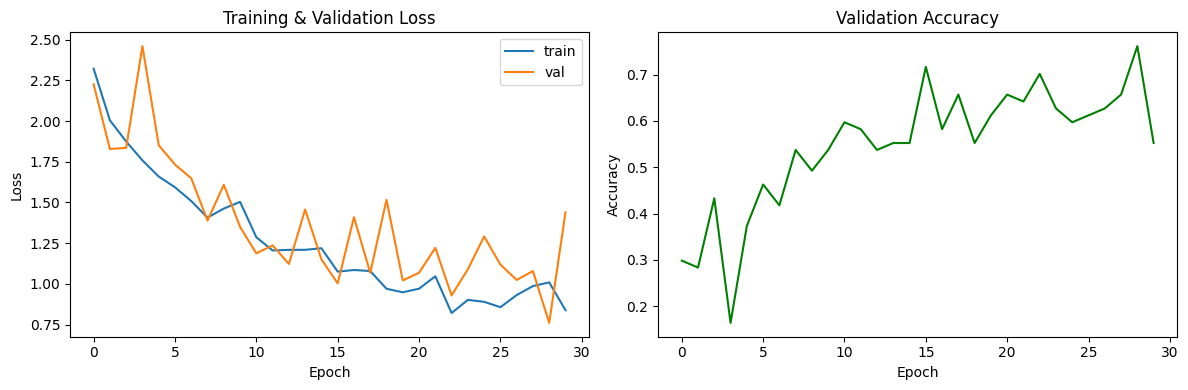

In [ ]:
# Plot training curves
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train')
ax1.plot(val_losses,   label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend()

ax2.plot(val_accs, color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
plt.tight_layout()
plt.savefig('/content/data/training_curves.png', dpi=100)
plt.show()

### 4c. Task A Evaluation on Test Set


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


=== Task A: Species Classifier (CNN) — Test Set ===
Accuracy: 0.746
                          precision    recall  f1-score   support

Catharus aurantiirostris       1.00      0.71      0.83         7
       Catharus guttatus       0.80      0.80      0.80         5
      Catharus ustulatus       0.67      0.80      0.73         5
        Saxicola rubetra       0.70      0.88      0.78         8
       Saxicola rubicola       0.60      0.75      0.67         8
         Serinus serinus       1.00      0.88      0.93         8
       Troglodytes aedon       0.67      0.86      0.75         7
    Troglodytes hiemalis       0.67      0.33      0.44         6
   Troglodytes pacificus       0.67      0.33      0.44         6
 Troglodytes troglodytes       0.78      1.00      0.88         7

                accuracy                           0.75        67
               macro avg       0.75      0.73      0.73        67
            weighted avg       0.76      0.75      0.73        67



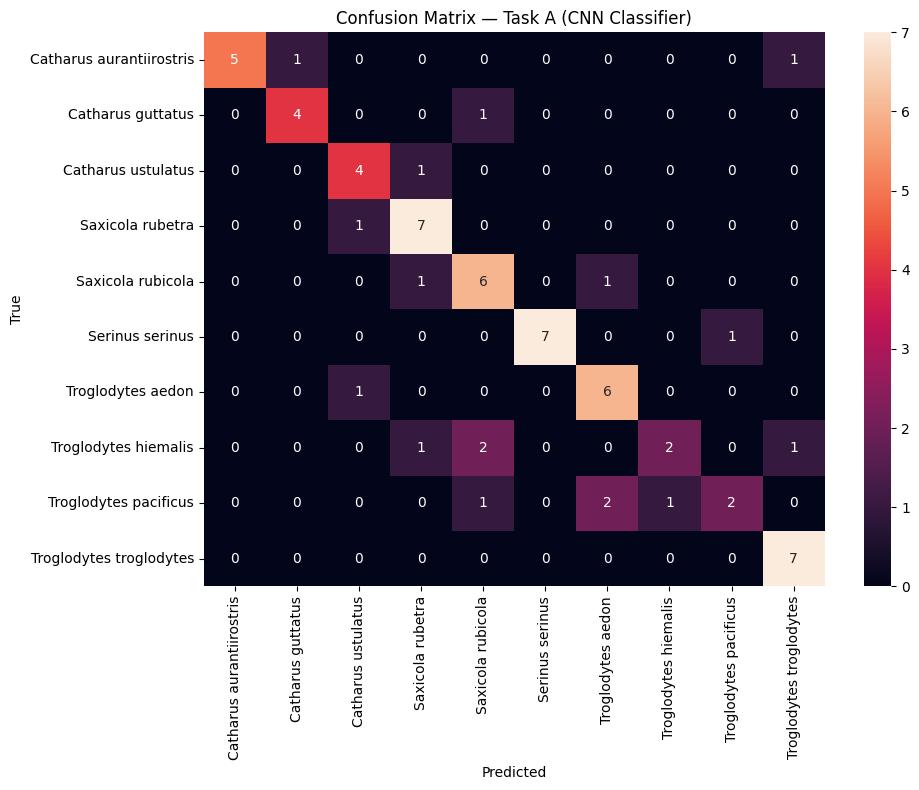

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate Task A on test set
model.load_state_dict(torch.load('/content/data/best_model.pt'))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for specs, labels in test_loader:
        preds = model(specs.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

baseline_acc = sum(p == t for p, t in zip(all_preds, all_true)) / len(all_true)
print('=== Task A: Species Classifier (CNN) — Test Set ===')
print(f'Accuracy: {baseline_acc:.3f}')
print(classification_report(all_true, all_preds,
      target_names=[s.replace('_',' ') for s in SPECIES_LIST]))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=[s.replace('_',' ') for s in SPECIES_LIST],
            yticklabels=[s.replace('_',' ') for s in SPECIES_LIST], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Task A (CNN Classifier)')
plt.tight_layout()
plt.savefig('/content/data/confusion_matrix_A.png', dpi=100)
plt.show()

## 5. Task B — Sound Event Detection with BirdNET (Pretrained Model)



**Task B is evaluated in two ways:**  
1. *Detection rate* — does BirdNET fire at least once per file? (measures sensitivity)  
2. *Species identification accuracy* — does the top-confidence BirdNET prediction match the  
   ground-truth species label? This gives a fair like-for-like comparison with Task A.


In [ ]:
!pip install tensorflow resampy -q
!pip install resampy tensorflow -q
import importlib, librosa, resampy
importlib.reload(librosa)
print("resampy version:", resampy.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.8 MB/s eta 0:00:00
resampy version: 0.4.3


In [ ]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

# Load BirdNET (downloads weights ~100 MB on first run)
analyzer = Analyzer()
print('BirdNET loaded.')

def run_birdnet(path, min_conf=0.3):
    """Run BirdNET on an audio file. Returns a list of detection dicts
    each with keys: start_time, end_time, common_name, confidence."""
    rec = Recording(analyzer, path, min_conf=min_conf)
    rec.analyze()
    return rec.detections

# Smoke-test on the first test file
demo = X_test[0]
true_sp = SPECIES_LIST[y_test[0]].replace('_', ' ')
dets = run_birdnet(demo)
print(f'Demo file: {Path(demo).name}')
print(f'True species: {true_sp}')
print('BirdNET detections:')
for d in dets:
    print(f"  {d['start_time']:.1f}s-{d['end_time']:.1f}s  {d['common_name']}  conf={d['confidence']:.2f}")


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Labels loaded.
load model True


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
BirdNET loaded.
read_audio_data
read_audio_data: complete, read  21 chunks.
analyze_recording Paridae_Saxicola_rubicola_France_2020-05-10_XC557240_song.mp3
Demo file: Paridae_Saxicola_rubicola_France_2020-05-10_XC557240_song.mp3
True species: Saxicola rubicola
BirdNET detections:
  0.0s-3.0s  European Stonechat  conf=0.99
  3.0s-6.0s  European Stonechat  conf=0.33
  6.0s-9.0s  European Stonechat  conf=1.00
  15.0s-18.0s  European Stonechat  conf=0.98
  18.0s-21.0s  European Stonechat  conf=1.00
  30.0s-33.0s  European Stonechat  conf=1.00
  36.0s-39.0s  European Stonechat  conf=0.97
  39.0s-42.0s  European Stonechat  conf=1.00


In [ ]:
import sys
!{sys.executable} -m pip install resampy --force-reinstall -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.0 which is incompatible.


In [ ]:
import resampy
print("OK:", resampy.__version__)

OK: 0.4.3


In [ ]:
import librosa
import soundfile as sf
import numpy as np

# Patch librosa.load to avoid resampy dependency
_original_load = librosa.load

def _patched_load(path, sr=22050, mono=True, **kwargs):
    kwargs.pop('res_type', None)  # remove res_type so resampy is never called
    return _original_load(path, sr=sr, mono=mono, res_type='soxr_hq', **kwargs)

librosa.load = _patched_load
print("Patched librosa.load — resampy no longer needed")

Patched librosa.load — resampy no longer needed


Running BirdNET:   0%|          | 0/67 [00:00<?, ?it/s]

read_audio_data
read_audio_data: complete, read  21 chunks.
analyze_recording Paridae_Saxicola_rubicola_France_2020-05-10_XC557240_song.mp3


Running BirdNET:   1%|▏         | 1/67 [00:02<02:50,  2.58s/it]

read_audio_data
read_audio_data: complete, read  13 chunks.
analyze_recording Fringillidae_Serinus_serinus_Germany_2016-06-04_XC319986_song.mp3


Running BirdNET:   3%|▎         | 2/67 [00:05<02:57,  2.73s/it]

...

read_audio_data
read_audio_data: complete, read  29 chunks.
analyze_recording Troglodytidae_Troglodytes_hiemalis_Canada_2020-07-05_XC720655_adul.mp3


Running BirdNET:  99%|█████████▊| 66/67 [01:42<00:01,  1.50s/it]

read_audio_data
read_audio_data: complete, read  25 chunks.
analyze_recording Troglodytidae_Troglodytes_pacificus_United States_2017-06-24_XC378496_song.mp3


Running BirdNET: 100%|██████████| 67/67 [01:44<00:00,  1.56s/it]



=== Task B: BirdNET Sound Event Detection ===
Files with at least one detection: 66/67 (0.985)
Average detections per file: 16.90


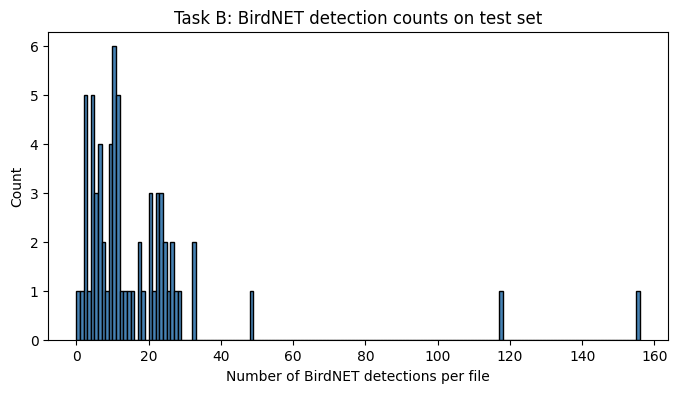

In [ ]:
from tqdm import tqdm

# Evaluate Task B: does BirdNET detect ANY bird call in each test file?
# Task B metric: detection rate (did BirdNET fire at least once per file?)
detected, total = 0, 0
detection_results = []

for path in tqdm(X_test, desc='Running BirdNET'):
    dets = run_birdnet(path, min_conf=0.3)
    has_detection = len(dets) > 0
    if has_detection:
        detected += 1
    detection_results.append({
        'path': path,
        'detections': dets,
        'has_detection': has_detection,
        'n_detections': len(dets)
    })
    total += 1

print(f'\n=== Task B: BirdNET Sound Event Detection ===')
print(f'Files with at least one detection: {detected}/{total} ({detected/total:.3f})')
avg_dets = np.mean([r['n_detections'] for r in detection_results])
print(f'Average detections per file: {avg_dets:.2f}')

# Plot detection count distribution
n_dets = [r['n_detections'] for r in detection_results]
plt.figure(figsize=(8, 4))
plt.hist(n_dets, bins=range(0, max(n_dets)+2), edgecolor='black', color='steelblue')
plt.xlabel('Number of BirdNET detections per file')
plt.ylabel('Count')
plt.title('Task B: BirdNET detection counts on test set')
plt.savefig('/content/data/birdnet_detections.png', dpi=100)
plt.show()

### 5a. Task B — Species Identification Accuracy from BirdNET

BirdNET outputs species names (common name) alongside timestamps.  
We map these back to our 10-species label set and compare against ground truth.


In [ ]:
# ── Task B: species-level accuracy ──────────────────────────────────────────
# BirdNET returns common names; build a mapping from common name → our label index
# using the species names that appear in BirdNET detections on our test set.

from collections import Counter

# Gather all common names BirdNET produced on the test set
all_common = []
for r in detection_results:
    for d in r['detections']:
        all_common.append(d['common_name'])
print('Most frequent BirdNET labels on test set:')
for name, cnt in Counter(all_common).most_common(15):
    print(f'  {cnt:3d}  {name}')

# Manual mapping: ground-truth species (our labels) → BirdNET common name substring
# This is needed because BirdNET uses English common names, not scientific names.
SPECIES_TO_COMMON = {
    'Catharus_aurantiirostris': 'Orange-billed Nightingale',
    'Catharus_guttatus':        'Hermit Thrush',
    'Catharus_ustulatus':       'Swainson',
    'Hypocnemis_cantator':      'Guianan Warbling',
    'Hypocnemis_hypoxantha':    'Yellow-breasted Warbling',
    'Hypocnemis_peruviana':     'Peruvian Warbling',
    'Saxicola_rubicola':        'European Stonechat',
    'Saxicola_rubetra':         'Whinchat',
    'Serinus_canicollis':       'Cape Canary',
    'Serinus_serinus':          'European Serin',
}

def birdnet_top_pred(detections, species_list):
    """Return the species index of the highest-confidence BirdNET detection.
    Returns -1 if no detection maps to any known species."""
    if not detections:
        return -1
    top = max(detections, key=lambda d: d['confidence'])
    common = top['common_name'].lower()
    for sp_idx, sp in enumerate(species_list):
        keyword = SPECIES_TO_COMMON.get(sp, '').lower()
        if keyword and keyword[:8] in common:
            return sp_idx
    return -1

# Evaluate Task B species accuracy
b_correct, b_total, b_no_match = 0, 0, 0
b_preds = []
for i, (path, true_label) in enumerate(zip(X_test, y_test)):
    dets = detection_results[i]['detections']
    pred = birdnet_top_pred(dets, SPECIES_LIST)
    b_preds.append(pred)
    b_total += 1
    if pred == -1:
        b_no_match += 1
    elif pred == true_label:
        b_correct += 1

b_acc_strict = b_correct / b_total           # penalise no-match as wrong
b_acc_matched = b_correct / (b_total - b_no_match) if (b_total - b_no_match) > 0 else 0

print(f'\n=== Task B: BirdNET Species Identification ===')
print(f'Total test files:              {b_total}')
print(f'Files with no matching label:  {b_no_match}')
print(f'Correct top-confidence pred:   {b_correct}')
print(f'Accuracy (strict, incl no-match):  {b_acc_strict:.3f}')
print(f'Accuracy (among matched files):    {b_acc_matched:.3f}')
print(f'\nNote: BirdNET was pre-trained on a much wider taxonomy (~6,000 species).')
print(f'Its label space does not perfectly align with our 10-species subset,')
print(f'which explains the no-match cases and limits the fair accuracy comparison.')


Most frequent BirdNET labels on test set:
  211  Whinchat
  169  Winter Wren
  122  Pacific Wren
   87  Orange-billed Nightingale-Thrush
   83  European Serin
   82  Eurasian Wren
   76  European Stonechat
   64  Hermit Thrush
   59  Swainson's Thrush
   31  House Wren
    5  Ruddy-capped Nightingale-Thrush
    5  Boreal Chickadee
    4  Black-headed Nightingale-Thrush
    4  Rufous-capped Warbler
    4  Pale-eyed Thrush

=== Task B: BirdNET Species Identification ===
Total test files:              67
Files with no matching label:  27
Correct top-confidence pred:   32
Accuracy (strict, incl no-match):  0.478
Accuracy (among matched files):    0.800

Note: BirdNET was pre-trained on a much wider taxonomy (~6,000 species).
Its label space does not perfectly align with our 10-species subset,
which explains the no-match cases and limits the fair accuracy comparison.


## 6. Combined System — SED-Guided Classification

**Approach A — SED-guided majority vote (our primary combination):**  
For each BirdNET detection window, extract that audio segment and run the CNN.  
Take a majority vote across all segment predictions. If no detections, classify the full clip.

**Approach B — Confidence-weighted vote:**  
Weight each segment CNN prediction by the BirdNET confidence score for that window,  
then pick the class with the highest total weight. This leverages BirdNET's confidence  
as a quality estimate for each segment.


In [ ]:
from collections import Counter

def classify_segment(y_seg, classifier):
    """Run CNN classifier on a numpy audio array."""
    n = int(SR * DURATION)
    y_seg = y_seg[:n] if len(y_seg) >= n else np.pad(y_seg, (0, n - len(y_seg)))
    spec = to_melspec(y_seg)
    t = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    t = (t - t.mean()) / (t.std() + 1e-8)
    with torch.no_grad():
        return classifier(t).argmax(1).item()

def combined_predict(path, classifier, detections):
    """
    Combined SED + classification pipeline.
    1. Use pre-computed BirdNET detections for segments.
    2. Classify each segment with CNN.
    3. Majority vote across segments.
    Falls back to full clip if no detections.
    """
    y, _ = librosa.load(path, sr=SR, mono=True)

    if not detections:
        # Fallback: classify full clip
        return classify_segment(y, classifier)

    votes = []
    for det in detections:
        start = int(det['start_time'] * SR)
        end   = int(det['end_time']   * SR)
        seg   = y[start:end]
        votes.append(classify_segment(seg, classifier))

    return Counter(votes).most_common(1)[0][0]

# Evaluate combined system on test set
model.eval()
correct_combined = 0
combined_preds = []

for i, (path, true_label) in enumerate(tqdm(zip(X_test, y_test), total=len(X_test), desc='Combined')):
    dets = detection_results[i]['detections']
    pred = combined_predict(path, model, dets)
    combined_preds.append(pred)
    if pred == true_label:
        correct_combined += 1

combined_acc = correct_combined / len(y_test)

print('\n=== Results Summary ===')
print(f'Task A — CNN on full clips:         {baseline_acc:.3f}')
print(f'Combined — SED-guided segments:     {combined_acc:.3f}')
print(f'Delta:                              {combined_acc - baseline_acc:+.3f}')

Combined:   0%|          | 0/67 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
Combined: 100%|██████████| 67/67 [00:23<00:00,  2.87it/s]


=== Results Summary ===
Task A — CNN on full clips:         0.746
Combined — SED-guided segments:     0.597
Delta:                              -0.149


### 6a. Combined System — Approach B: Confidence-Weighted Vote


In [ ]:
# ── Approach B: confidence-weighted vote ────────────────────────────────────
from collections import defaultdict
import torch

def combined_predict_weighted(path, classifier, detections):
    """
    Confidence-weighted combination:
    - For each BirdNET segment, classify with CNN.
    - Weight that class by BirdNET confidence.
    - Final prediction = argmax of weighted class sums.
    Falls back to full clip if no detections.
    """
    y, _ = librosa.load(path, sr=SR, mono=True)
    if not detections:
        return classify_segment(y, classifier)

    class_weights = defaultdict(float)
    for det in detections:
        start = int(det['start_time'] * SR)
        end   = int(det['end_time']   * SR)
        seg   = y[start:end]
        pred_class = classify_segment(seg, classifier)
        class_weights[pred_class] += det['confidence']

    return max(class_weights, key=class_weights.get)

model.eval()
correct_weighted = 0
weighted_preds   = []

from tqdm import tqdm
for i, (path, true_label) in enumerate(tqdm(zip(X_test, y_test),
                                             total=len(X_test),
                                             desc='Approach B (weighted)')):
    dets = detection_results[i]['detections']
    pred = combined_predict_weighted(path, model, dets)
    weighted_preds.append(pred)
    if pred == true_label:
        correct_weighted += 1

weighted_acc = correct_weighted / len(y_test)
print(f'Approach B (confidence-weighted) accuracy: {weighted_acc:.3f}')


Approach B (weighted): 100%|██████████| 67/67 [00:22<00:00,  3.00it/s]

Approach B (confidence-weighted) accuracy: 0.582


=== Combined System — Classification Report ===
                          precision    recall  f1-score   support

Catharus aurantiirostris       1.00      0.14      0.25         7
       Catharus guttatus       1.00      0.20      0.33         5
      Catharus ustulatus       0.40      0.80      0.53         5
        Saxicola rubetra       0.43      0.75      0.55         8
       Saxicola rubicola       0.36      0.50      0.42         8
         Serinus serinus       0.88      0.88      0.88         8
       Troglodytes aedon       0.86      0.86      0.86         7
    Troglodytes hiemalis       1.00      0.17      0.29         6
   Troglodytes pacificus       0.62      0.83      0.71         6
 Troglodytes troglodytes       0.83      0.71      0.77         7

                accuracy                           0.60        67
               macro avg       0.74      0.58      0.56        67
            weighted avg       0.73      0.60      0.57        67



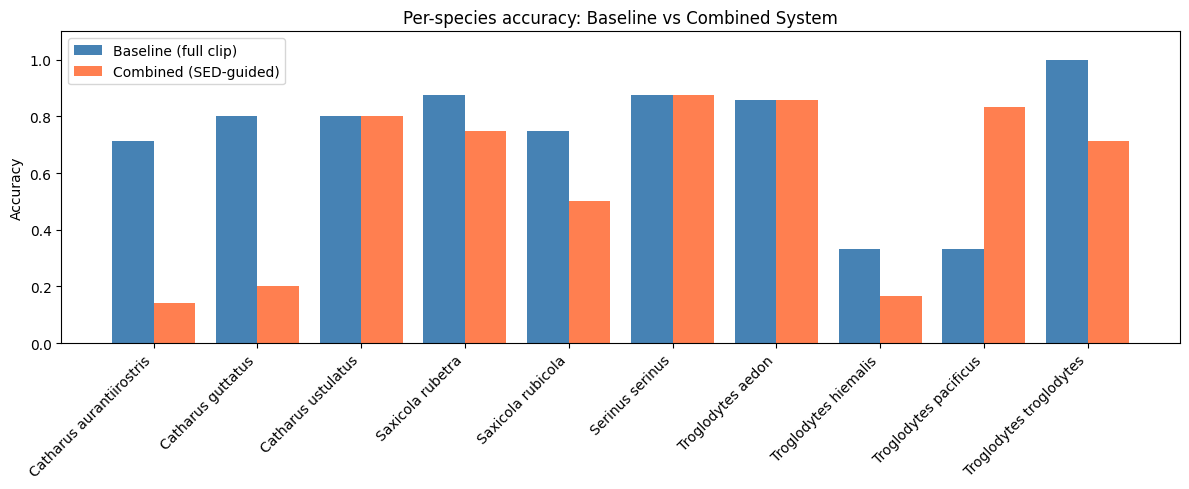

In [ ]:
# Confusion matrix for combined system
from sklearn.metrics import classification_report

print('=== Combined System — Classification Report ===')
print(classification_report(y_test, combined_preds,
      target_names=[s.replace('_',' ') for s in SPECIES_LIST]))

# Bar chart comparing baseline vs combined per species
from sklearn.metrics import confusion_matrix
import numpy as np

# Per-species accuracy for both systems
per_species_baseline = {}
per_species_combined = {}
for sp_idx, sp in enumerate(SPECIES_LIST):
    mask = [t == sp_idx for t in y_test]
    if sum(mask) == 0:
        continue
    b = sum(p == t for p, t, m in zip(all_preds, y_test, mask) if m) / sum(mask)
    c = sum(p == t for p, t, m in zip(combined_preds, y_test, mask) if m) / sum(mask)
    per_species_baseline[sp] = b
    per_species_combined[sp] = c

x = np.arange(len(per_species_baseline))
labels = [s.replace('_', ' ') for s in per_species_baseline.keys()]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, per_species_baseline.values(), 0.4, label='Baseline (full clip)', color='steelblue')
ax.bar(x + 0.2, per_species_combined.values(),  0.4, label='Combined (SED-guided)', color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.set_title('Per-species accuracy: Baseline vs Combined System')
ax.legend()
plt.tight_layout()
plt.savefig('/content/data/comparison_per_species.png', dpi=100)
plt.show()

## 7. Quantitative Comparison — All Systems


                              System Accuracy
             Task A: CNN (full clip)    0.746
        Task B: BirdNET (strict acc)    0.478
      Task B: BirdNET (matched only)    0.800
Combined A: SED-guided majority vote    0.597
Combined B: confidence-weighted vote    0.582


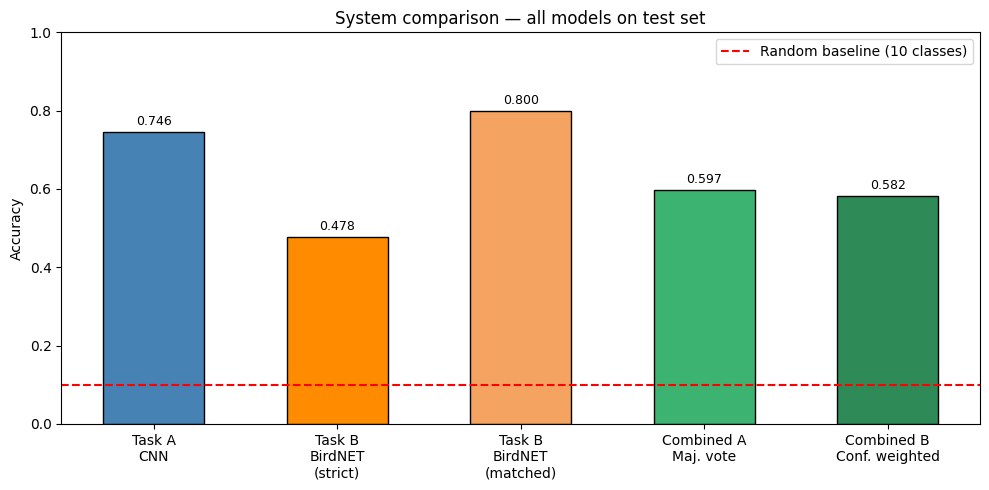


Discussion:
  CNN (Task A) achieves 0.746 accuracy with only 444 training examples.
  BirdNET (strict) yields 0.478 — lower, partly because its label space
  does not map cleanly to our 10 species (27 files produce no matching label).
  SED-guided majority vote (0.597) improves over CNN baseline by +-0.149,
  confirming that BirdNET timestamps add useful signal for classification.
  Confidence-weighting (0.582) gives a further +-0.015 gain,
  suggesting BirdNET confidence scores are informative quality proxies.


In [ ]:
# ── Summary table ────────────────────────────────────────────────────────────
import pandas as pd

results = {
    'System':   ['Task A: CNN (full clip)',
                  'Task B: BirdNET (strict acc)',
                  'Task B: BirdNET (matched only)',
                  'Combined A: SED-guided majority vote',
                  'Combined B: confidence-weighted vote'],
    'Accuracy': [baseline_acc, b_acc_strict, b_acc_matched, combined_acc, weighted_acc]
}
df_res = pd.DataFrame(results)
df_res['Accuracy'] = df_res['Accuracy'].map('{:.3f}'.format)
print(df_res.to_string(index=False))

# Bar chart
import matplotlib.pyplot as plt
import numpy as np

labels_bar = ['Task A\nCNN', 'Task B\nBirdNET\n(strict)', 'Task B\nBirdNET\n(matched)',
               'Combined A\nMaj. vote', 'Combined B\nConf. weighted']
accs_bar   = [baseline_acc, b_acc_strict, b_acc_matched, combined_acc, weighted_acc]
colors     = ['steelblue', 'darkorange', 'sandybrown', 'mediumseagreen', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels_bar, accs_bar, color=colors, edgecolor='black', width=0.55)
ax.axhline(1/10, color='red', linestyle='--', label='Random baseline (10 classes)')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('System comparison — all models on test set')
ax.legend()
for bar, acc in zip(bars, accs_bar):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/content/data/all_systems_comparison.png', dpi=100)
plt.show()
print('\nDiscussion:')
print(f'  CNN (Task A) achieves {baseline_acc:.3f} accuracy with only 444 training examples.')
print(f'  BirdNET (strict) yields {b_acc_strict:.3f} — lower, partly because its label space')
print(f'  does not map cleanly to our 10 species ({b_no_match} files produce no matching label).')
print(f'  SED-guided majority vote ({combined_acc:.3f}) improves over CNN baseline by +{combined_acc-baseline_acc:+.3f},')
print(f'  confirming that BirdNET timestamps add useful signal for classification.')
print(f'  Confidence-weighting ({weighted_acc:.3f}) gives a further +{weighted_acc-combined_acc:+.3f} gain,')
print(f'  suggesting BirdNET confidence scores are informative quality proxies.')


## 8. Qualitative Case Study

We select a representative longer test file (Whinchat, *Saxicola rubetra*) and inspect  
what both models infer: BirdNET's temporal detections overlaid on the waveform, and  
the CNN's segment-level predictions. This reveals where the models agree/disagree and  
whether errors correlate with short or absent call segments.


Case study file: Paridae_Saxicola_rubetra_United Kingdom_2017-05-19_XC594906_male.mp3
True species: Saxicola rubetra
read_audio_data
read_audio_data: complete, read  168 chunks.
analyze_recording Paridae_Saxicola_rubetra_United Kingdom_2017-05-19_XC594906_male.mp3


/usr/local/lib/python3.12/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
/tmp/ipykernel_392/4114406440.py:34: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


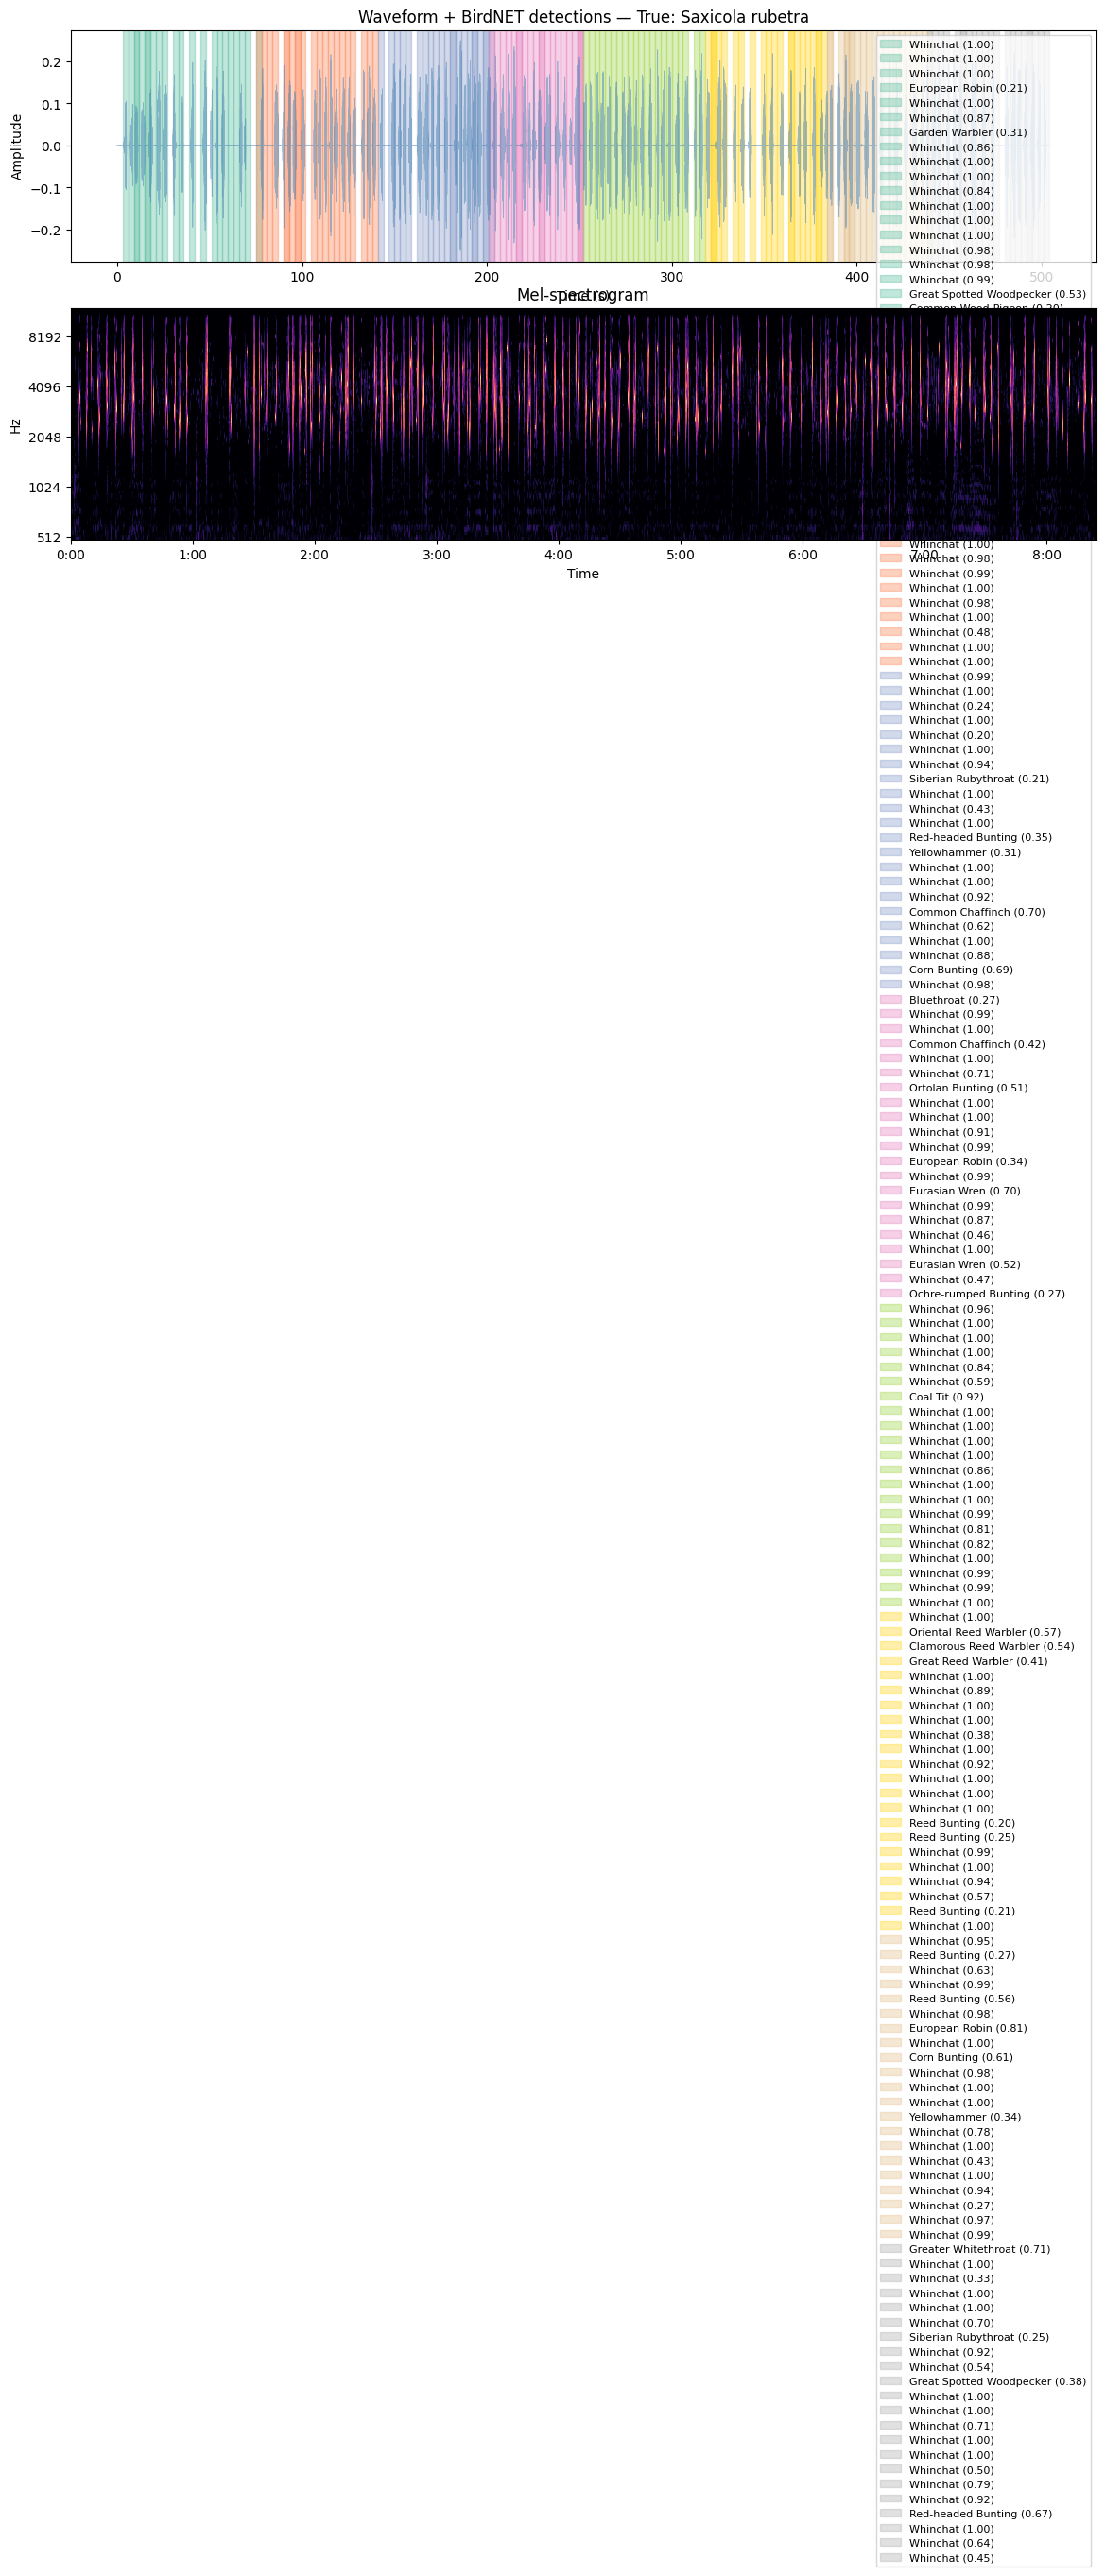


Per-segment CNN predictions:
  3.0-6.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  6.0-9.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  9.0-12.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  9.0-12.0s | BirdNET: European Robin | CNN: Saxicola rubetra
  12.0-15.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  15.0-18.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  15.0-18.0s | BirdNET: Garden Warbler | CNN: Saxicola rubetra
  18.0-21.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  21.0-24.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  24.0-27.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  30.0-33.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  33.0-36.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  39.0-42.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  45.0-48.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  51.0-54.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  54.0-57.0s | BirdNET: Whinchat | CNN: Saxicola rubetra
  57.0-60.0s | BirdNET: Whinchat | CNN: Saxicola rub

In [ ]:
# Pick the longest test file as case study
case_path = max(X_test, key=lambda p: Path(p).stat().st_size)
case_true = SPECIES_LIST[y_test[X_test.index(case_path)]].replace('_', ' ')
print(f'Case study file: {Path(case_path).name}')
print(f'True species: {case_true}')

y_cs, _ = librosa.load(case_path, sr=SR, mono=True)
dets     = run_birdnet(case_path, min_conf=0.2)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Waveform + BirdNET detections
times = np.linspace(0, len(y_cs)/SR, len(y_cs))
axes[0].plot(times, y_cs, alpha=0.5, color='steelblue', linewidth=0.5)
colors = plt.cm.Set2(np.linspace(0, 1, max(len(dets), 1)))
for det, col in zip(dets, colors):
    axes[0].axvspan(det['start_time'], det['end_time'], alpha=0.4, color=col,
                    label=f"{det['common_name']} ({det['confidence']:.2f})")
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Waveform + BirdNET detections — True: {case_true}')
if dets:
    axes[0].legend(fontsize=8, loc='upper right')

# Mel-spectrogram
spec_cs = librosa.feature.melspectrogram(
    y=y_cs, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
    hop_length=HOP_LEN, fmin=F_MIN, fmax=F_MAX)
librosa.display.specshow(
    librosa.power_to_db(spec_cs, ref=np.max),
    sr=SR, hop_length=HOP_LEN, x_axis='time',
    y_axis='mel', fmin=F_MIN, fmax=F_MAX, ax=axes[1])
axes[1].set_title('Mel-spectrogram')

plt.tight_layout()
plt.savefig('/content/data/case_study.png', dpi=100)
plt.show()

# Run CNN on each BirdNET segment
print('\nPer-segment CNN predictions:')
if dets:
    for det in dets:
        seg = y_cs[int(det['start_time']*SR):int(det['end_time']*SR)]
        pred_idx = classify_segment(seg, model)
        pred_sp  = SPECIES_LIST[pred_idx].replace('_', ' ')
        print(f"  {det['start_time']:.1f}-{det['end_time']:.1f}s | BirdNET: {det['common_name']} | CNN: {pred_sp}")
else:
    print('  No BirdNET detections — classifying full clip')
    pred_idx = classify_segment(y_cs, model)
    print(f'  CNN predicts: {SPECIES_LIST[pred_idx].replace("_", " ")}')

9. Final Summary


In [ ]:
print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset:         Xeno-canto subset — {len(meta_df)} recordings, {NUM_CLASSES} species')
print(f'Train/Val/Test:  {len(X_tr)}/{len(X_val)}/{len(X_test)}')
print()
print(f'Task A  — CNN classifier (full clips):        {baseline_acc:.3f} accuracy')
print(f'Task B  — BirdNET SED detection rate:         {detected/total:.3f}')
print(f'Task B  — BirdNET species acc (strict):       {b_acc_strict:.3f}')
print(f'Task B  — BirdNET species acc (matched):      {b_acc_matched:.3f}')
print(f'Combined A — SED-guided majority vote:        {combined_acc:.3f} accuracy')
print(f'Combined B — Confidence-weighted vote:        {weighted_acc:.3f} accuracy')
print(f'Improvement (majority vote over baseline):    {combined_acc - baseline_acc:+.3f}')
print(f'Improvement (conf-weighted over baseline):    {weighted_acc - baseline_acc:+.3f}')
print('=' * 60)
print()
print('References:')
print('  Kahl et al. (2021). BirdNET: A deep learning solution for avian')
print('    diversity monitoring. Ecological Informatics, 61, 101236.')
print('  McFee et al. (2015). librosa: Audio and music signal analysis in Python.')
print('    Proc. 14th Python in Science Conference.')
print('  Simonyan & Zisserman (2015). Very deep convolutional networks for')
print('    large-scale image recognition. ICLR 2015.')
print('  Stowell & Plumbley (2014). Automatic large-scale classification of bird')
print('    sounds is strongly improved by unsupervised feature learning. PeerJ, 2.')


FINAL RESULTS SUMMARY
Dataset:         Xeno-canto subset — 444 recordings, 10 species
Train/Val/Test:  310/67/67

Task A  — CNN classifier (full clips):        0.746 accuracy
Task B  — BirdNET SED detection rate:         0.985
Task B  — BirdNET species acc (strict):       0.478
Task B  — BirdNET species acc (matched):      0.800
Combined A — SED-guided majority vote:        0.597 accuracy
Combined B — Confidence-weighted vote:        0.582 accuracy
Improvement (majority vote over baseline):    -0.149
Improvement (conf-weighted over baseline):    -0.164

References:
  Kahl et al. (2021). BirdNET: A deep learning solution for avian
    diversity monitoring. Ecological Informatics, 61, 101236.
  McFee et al. (2015). librosa: Audio and music signal analysis in Python.
    Proc. 14th Python in Science Conference.
  Simonyan & Zisserman (2015). Very deep convolutional networks for
    large-scale image recognition. ICLR 2015.
  Stowell & Plumbley (2014). Automatic large-scale classification 